<a href="https://colab.research.google.com/github/TeddyAbraham/Porter-NN-Regression/blob/main/Porter_NN_Regression%26Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Porter NN Regression


Porter is India's Largest Marketplace for Intra-City Logistics. Leader in the country's $40 billion intra-city logistics market, Porter strives to improve the lives of 1,50,000+ driver-partners by providing them with consistent earning & independence. Currently, the company has serviced 5+ million customers

Porter works with a wide range of restaurants for delivering their items directly to the people.

### Problem statement
Porter has a number of delivery partners available for delivering the food, from various restaurants and wants to get an estimated delivery time that it can provide the customers on the basis of what they are ordering, from where and also the delivery partners.

This dataset has the required data to train a regression model that will do the delivery time esimation, based on all those features

### Data Dictionary
- market_id : integer id for the market where the restaurant lies
- created_at : the timestamp at which the order was placed
- actual_delivery_time : the timestamp when the order was delivered
- store_id : encoded id for different stores
- order_protocol : integer code value for order protocol(how the order was placed ie: through porter, call to restaurant, prebooked, third part etc)
- total_items : total item purchase
- subtotal : final price of the order
- num_distinct_items : the number of distinct items in the order
- min_item_price : price of the cheapest item in the order
- max_item_price : price of the costliest item in order
- total_onshift_partners : number of delivery partners on duty at the time order was placed
- total_busy_partners : number of delivery partners attending to other tasks
- total_outstanding_orders : total number of orders to be fulfilled at the moment
- estimated_store_to_consumer_driving_duration : approximate travel time from restaurant to customer

broad steps in the notebook

- load the data and understand the features
- feature engineering creating target variable(time taken for each order)
- cleaning the data and visualization
- preparing the data for training
- random forest regression
- neural network regression
- comarision of both ways

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import os

# |-------Visualization------|
import matplotlib.pyplot as plt
import seaborn as sns

# |-------Testing------|
from scipy import stats
from statsmodels.stats.weightstats import ztest
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency

# |-------Machine Learning------|
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# |-------Neural Network------|
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import MeanSquaredLogarithmicError, MeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError

In [2]:
!gdown 1ecuaWt7IDE9FroHDrOoQLdmyfKe6PLmv

Downloading...
From: https://drive.google.com/uc?id=1ecuaWt7IDE9FroHDrOoQLdmyfKe6PLmv
To: /content/Porter NN Regression.csv
100% 15.7M/15.7M [00:00<00:00, 145MB/s]


In [3]:
# Load dataset
df = pd.read_csv("/content/Porter NN Regression.csv", parse_dates=[1, 2])
df.head(5)

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [4]:
df.shape

(175777, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     175777 non-null  float64       
 1   created_at                                    175777 non-null  datetime64[ns]
 2   actual_delivery_time                          175777 non-null  datetime64[ns]
 3   store_primary_category                        175777 non-null  int64         
 4   order_protocol                                175777 non-null  float64       
 5   total_items                                   175777 non-null  int64         
 6   subtotal                                      175777 non-null  int64         
 7   num_distinct_items                            175777 non-null  int64         
 8   min_item_price                                175777 n

- Data Looks clean, with no null values.
- Both the datetime columns have datetime as their Dtype, so need not to convert however few more feature engineering need to be done. (actual_delivery_time - created_at) to get the Actual time taken.
- Also feature Engineering to get Hour and day of week to get the order trend.


In [6]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

In [7]:
df['Actual_time_taken'] = df['actual_delivery_time'] - df['created_at']
df['Actual_time_taken'] = df['Actual_time_taken'].dt.total_seconds().astype(int)/60
df['created_hour'] = df['created_at'].dt.hour
df['delivery_hour'] = df['actual_delivery_time'].dt.hour
df['delivery_week_day'] = df['actual_delivery_time'].dt.weekday
df['Approx_Resto_prep_time_min'] = (
    df['Actual_time_taken'] - df['estimated_store_to_consumer_driving_duration']/60
).clip(lower=0)
df['estimated_store_to_consumer_driving_duration'] = df['estimated_store_to_consumer_driving_duration'] / 60

In [8]:
df['utilization_rate'] = df['total_busy_dashers'] / df['total_onshift_dashers']
df['orders_per_dasher'] = df['total_outstanding_orders'] / df['total_busy_dashers']
df['supply_gap'] = df['total_onshift_dashers'] - df['total_busy_dashers']
df['demand_supply_ratio'] = df['total_outstanding_orders'] / df['total_onshift_dashers']

In [9]:
df['staffing_level'] = pd.cut(df['utilization_rate'], bins=[0, 0.6, 0.85, 1], labels=['Overstaffed', 'Optimal', 'Understaffed'])


- estimated_store_to_consumer_driving_duration is in seconds we need to check from **actual time taken **-** estimated_store_to_consumer_driving_duration** will be the approximate time the restaurant taking to prepare the meal.<br>
*( Note that it just gives the estimation, the restaurant might have prepare the order before and kept but the delivery person might get delayed)*
- A separate data point to check the **order_prepared_time** will be better to see how much delay from the time of order_prepared_time to the delivery pick up time, so that the time wastage can be minimised

In [10]:
df['dasher_load'] = df['total_busy_dashers'] / df['total_onshift_dashers']
df['avg_item_price'] = df['subtotal'] / df['total_items']

In [11]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,...,delivery_hour,delivery_week_day,Approx_Resto_prep_time_min,utilization_rate,orders_per_dasher,supply_gap,demand_supply_ratio,staffing_level,dasher_load,avg_item_price
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,...,23,4,32.650000,0.424242,1.500000,19.0,0.636364,Overstaffed,0.424242,860.25
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,...,22,1,32.500000,2.000000,1.000000,-1.0,2.000000,NaN,2.000000,1900.00
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,...,1,0,50.183333,0.750000,3.000000,2.0,2.250000,Optimal,0.750000,1192.75
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,...,4,3,45.750000,1.200000,1.333333,-1.0,1.600000,NaN,1.200000,1525.00
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,...,2,1,42.583333,1.000000,1.400000,0.0,1.400000,Understaffed,1.000000,1810.00


In [12]:
df.describe().T

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,count,mean,min,25%,50%,75%,max,std
market_id,175777.0,2.743726,1.0,2.0,2.0,4.0,6.0,1.330963
created_at,175777,2015-02-04 19:57:50.009631744,2015-01-21 15:22:03,2015-01-29 01:31:19,2015-02-05 02:41:26,2015-02-12 01:04:32,2015-02-18 06:00:44,NaN
actual_delivery_time,175777,2015-02-04 20:44:02.190406144,2015-01-21 16:07:03,2015-01-29 02:16:30,2015-02-05 03:34:33,2015-02-12 01:48:24,2015-02-18 06:51:10,NaN
store_primary_category,175777.0,35.887949,0.0,18.0,38.0,55.0,72.0,20.728254
order_protocol,175777.0,2.911752,1.0,1.0,3.0,4.0,7.0,1.513128
total_items,175777.0,3.204976,1.0,2.0,3.0,4.0,411.0,2.674055
subtotal,175777.0,2697.111147,0.0,1412.0,2224.0,3410.0,26800.0,1828.554893
num_distinct_items,175777.0,2.67506,1.0,1.0,2.0,3.0,20.0,1.625681
min_item_price,175777.0,684.965433,-86.0,299.0,595.0,942.0,14700.0,519.882924
max_item_price,175777.0,1160.158616,0.0,799.0,1095.0,1395.0,14700.0,560.828571


- Market id -  There are 6 different Market Ids
- Data Collected from 2015-01-21 to 2015-02-18, less 1 months data.
- store_primary_category - 72 different store category
- order_protocol - 7 different places from where the orders were placed.
- Mostly people purchase 3 or 4 items, however we have outliers upto 400 items
- Most purchase value around 3000 to 4000, however min_item_price are also in negative, which indicates either refunds or data quality issue, **Need to fix before modelling.
- Delivery time ranges from 32 min → 110 min, Median delivery time: 45 minutes.
- Most orders are small basket orders (2–3 items).
- Median for Onshift dashers -37<br>
  Busy dashers -35<br>
  Outstanding orders -41
  *Busy dashers* are almost equal to *total dashers*, indicating high utilization. But as outstanding orders are more the platform should increase dasher supply during peak hours.
- estimated_store_to_consumer_driving_duration time is much smaller than total delivery time. Delivery delays are likely coming from:
    - Restaurant preparation time
    - Order assignment delays
    - Dasher availability
- Data Quality Issues : min_item_price, total_onshift_dashers, total_busy_dashers, total_outstanding_orders cannot be having negative value

In [13]:
# Removing the negative values
df['min_item_price'] = np.where(df['min_item_price'] < 0, 0, df['min_item_price'])

df = df[df['total_onshift_dashers'] >= 0]
df = df[df['total_busy_dashers'] >= 0]
df = df[df['total_outstanding_orders'] >= 0]

### Uni_Varient Analysis

In [14]:
for i in df.columns:
  print(f"{i} : {df[i].nunique()}")

market_id : 6
created_at : 162578
actual_delivery_time : 160275
store_primary_category : 73
order_protocol : 7
total_items : 54
subtotal : 8180
num_distinct_items : 20
min_item_price : 2233
max_item_price : 2580
total_onshift_dashers : 168
total_busy_dashers : 153
total_outstanding_orders : 275
estimated_store_to_consumer_driving_duration : 1318
Actual_time_taken : 74
created_hour : 19
delivery_hour : 18
delivery_week_day : 7
Approx_Resto_prep_time_min : 3819
utilization_rate : 3985
orders_per_dasher : 5123
supply_gap : 145
demand_supply_ratio : 5269
staffing_level : 3
dasher_load : 3985
avg_item_price : 17767


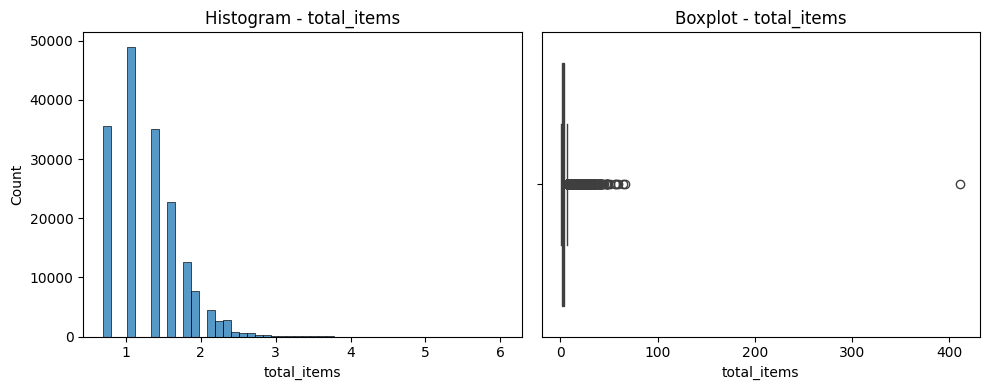

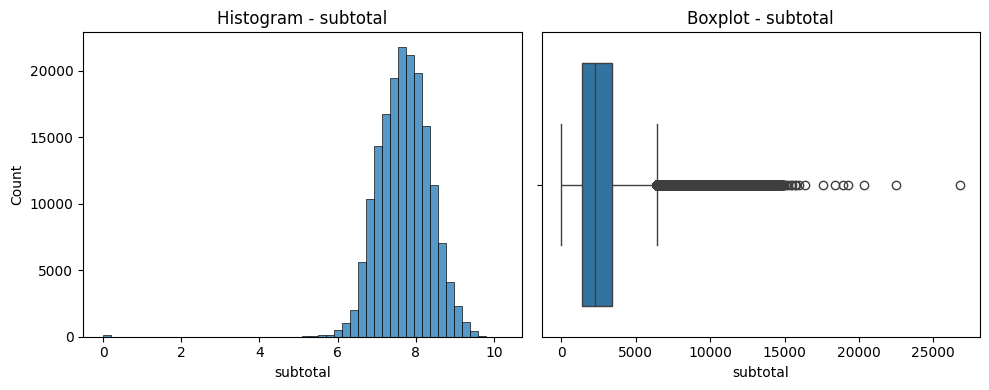

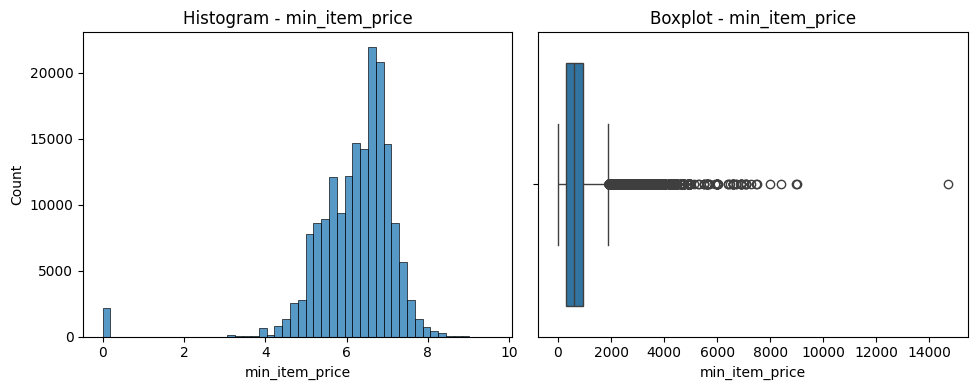

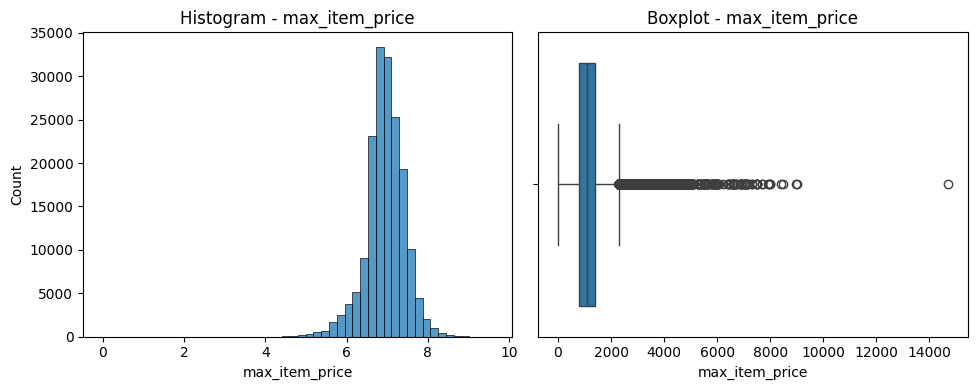

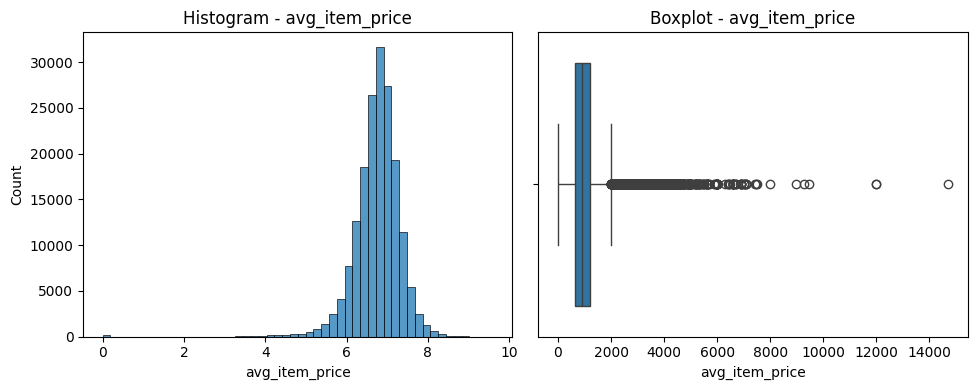

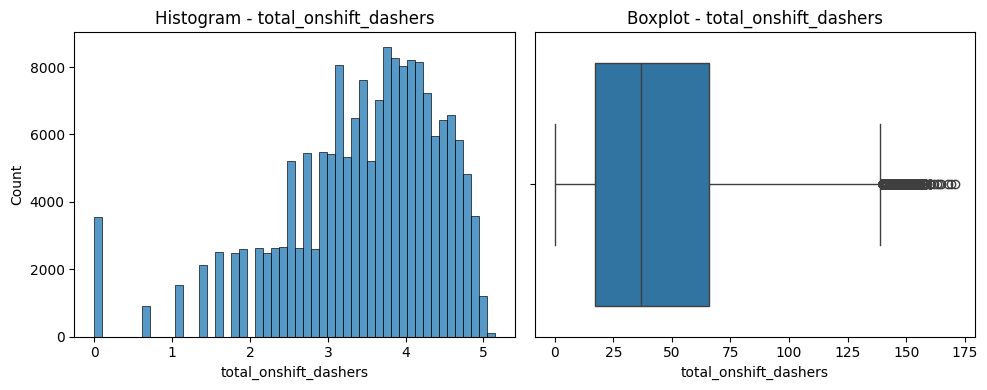

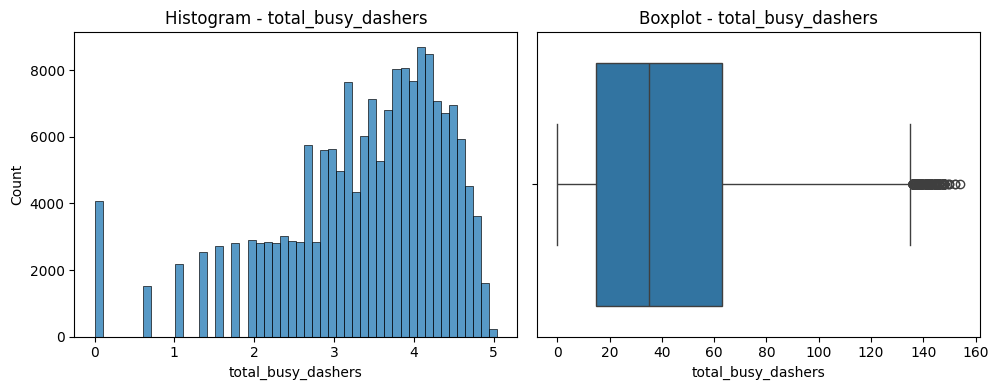

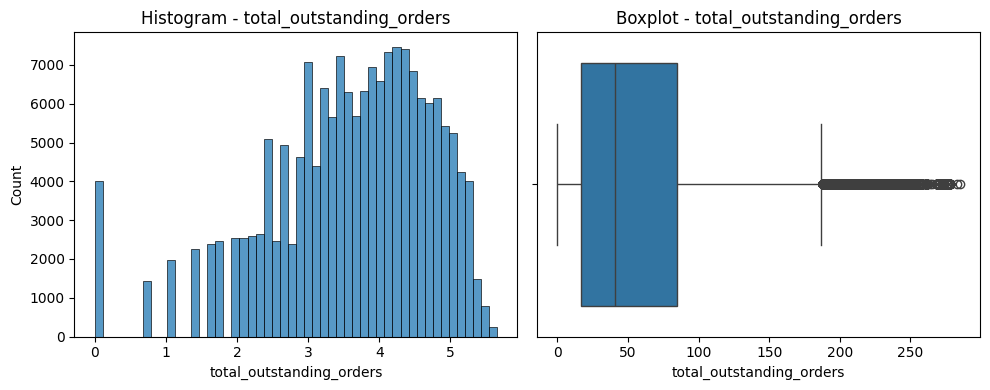

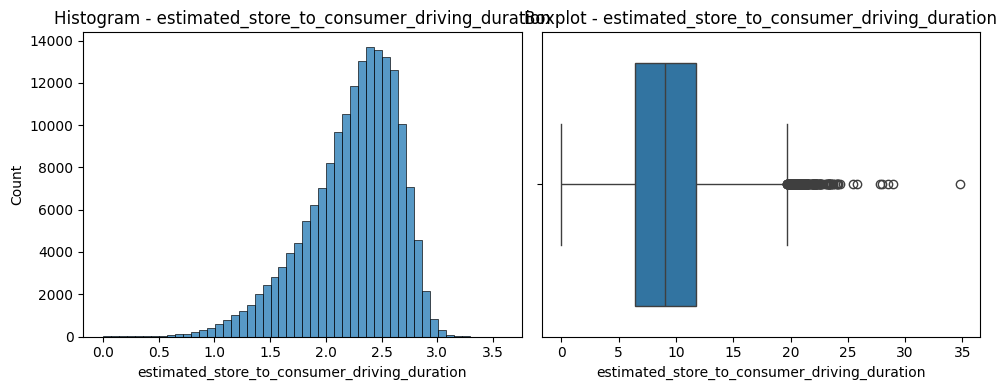

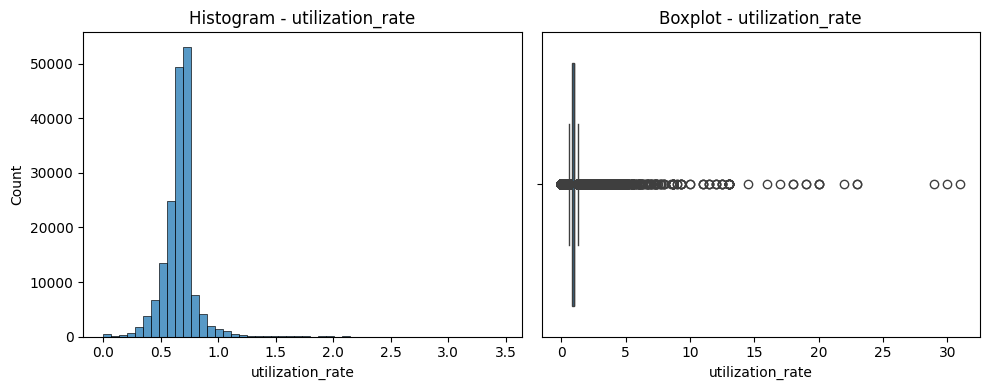

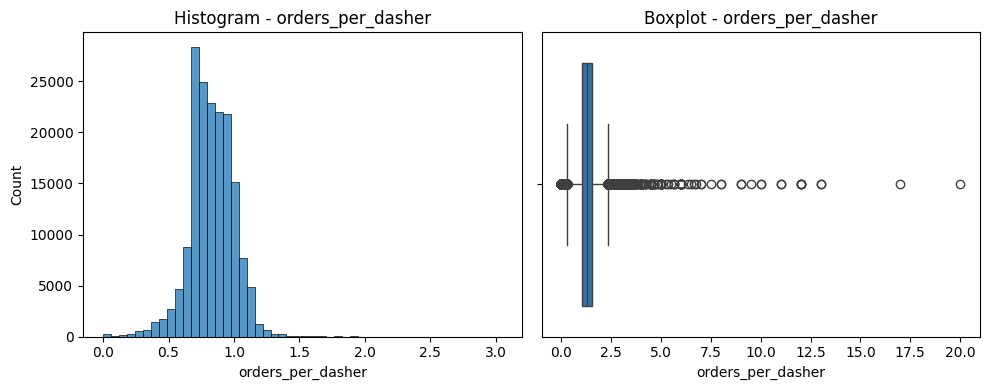

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


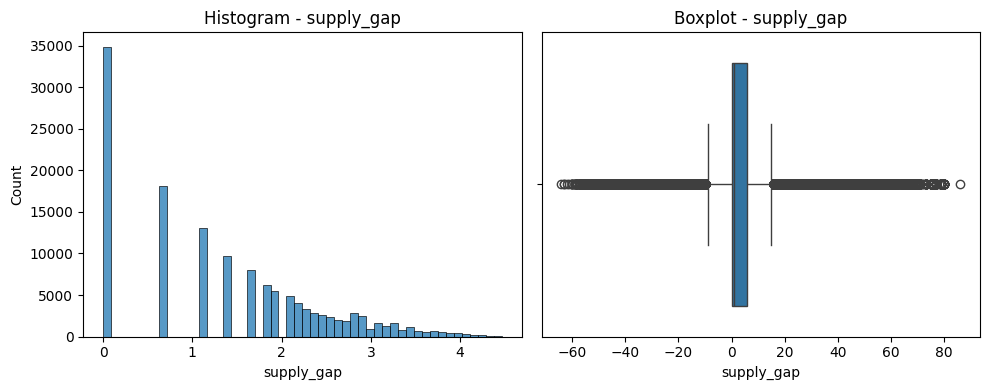

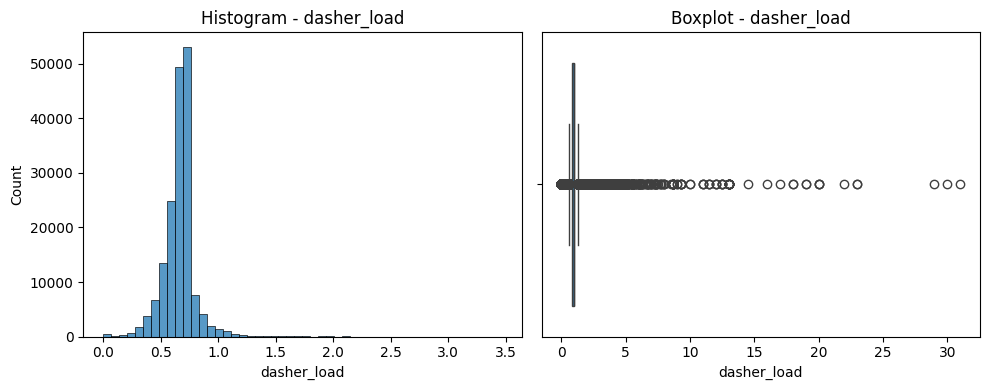

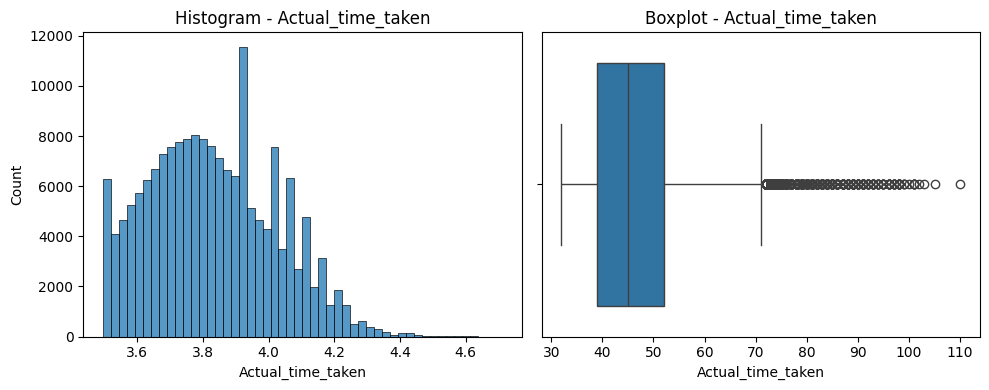

In [15]:
num_uni = ['total_items', 'subtotal', 'min_item_price', 'max_item_price', 'avg_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
           'estimated_store_to_consumer_driving_duration', 'utilization_rate', 'orders_per_dasher', 'supply_gap', 'dasher_load', 'Actual_time_taken' ]
for col in num_uni:

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram (NO KDE, NO tiny binwidth)

    sns.histplot(np.log1p(df[col]), bins=50, ax = axes[0])
    # sns.histplot(df[col], bins=50, ax=axes[0])
    axes[0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot - {col}')

    plt.tight_layout()
    plt.show()

#### Removing outliers

In [16]:
def removing_outliers(df, col):
  Q1 = df[col].quantile(.25)
  Q3 = df[col].quantile(.75)
  IQR = (Q3-Q1)
  upper_bound = Q3 + 1.5 * IQR
  lower_bound = Q1 - 1.5 * IQR

  df[col] = df[col].clip(lower = lower_bound, upper = upper_bound)
  return df

for col in num_uni:
  df1 = removing_outliers(df, col)



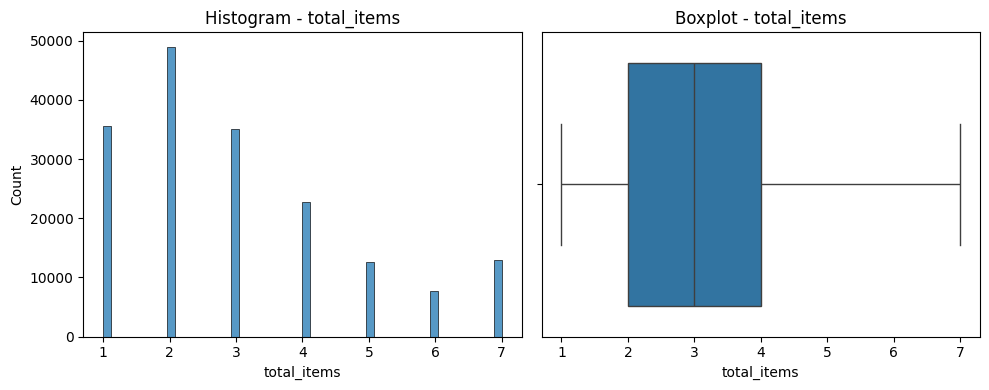

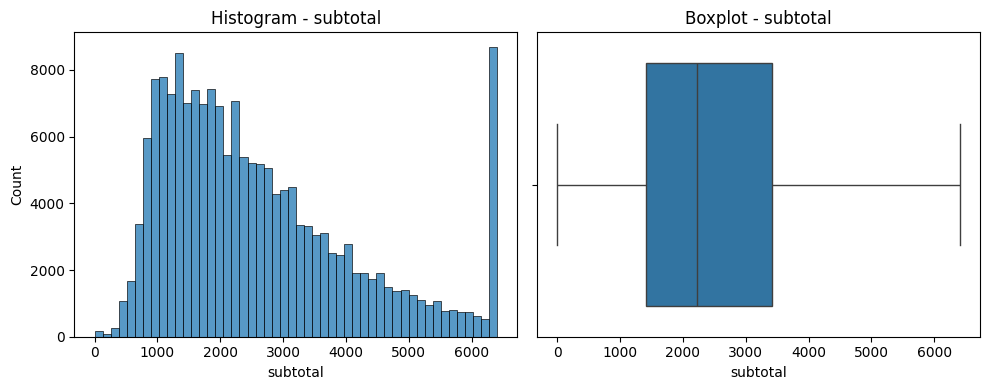

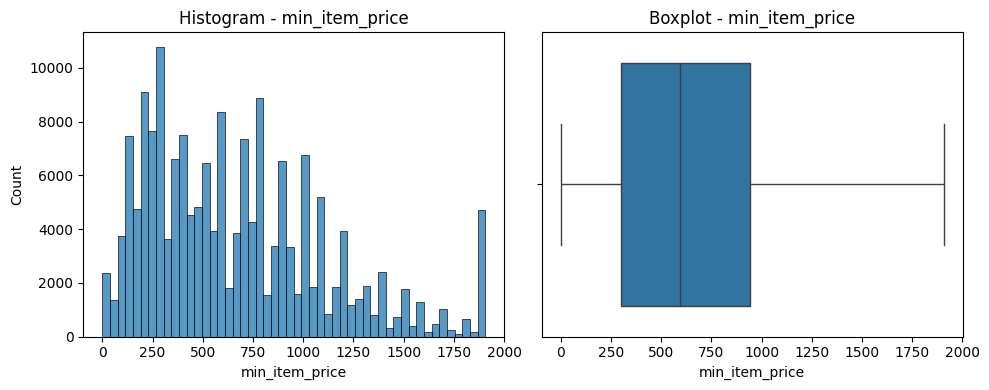

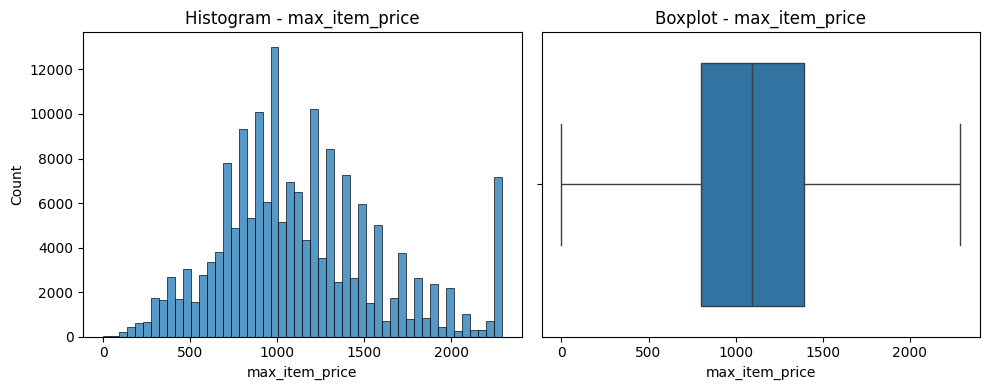

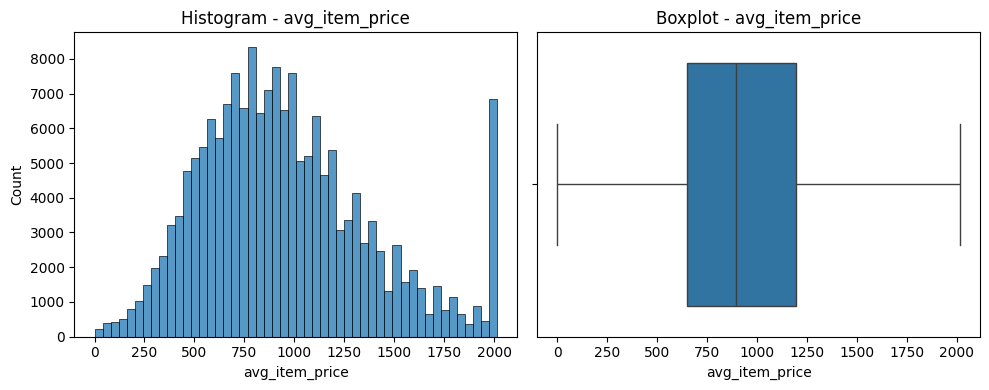

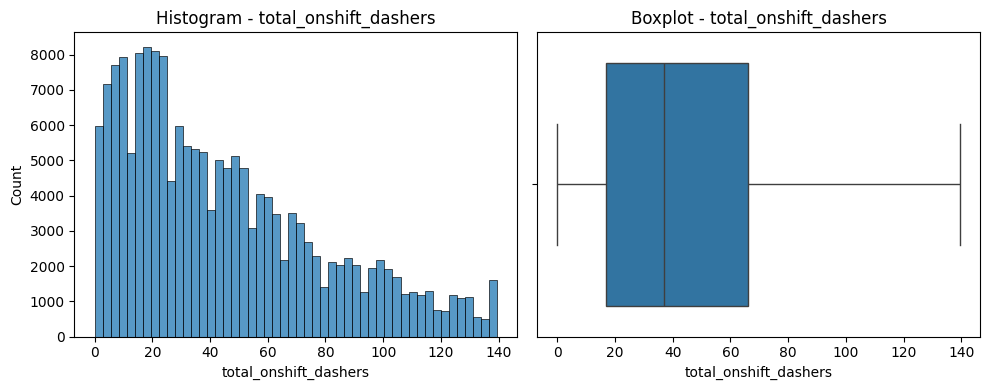

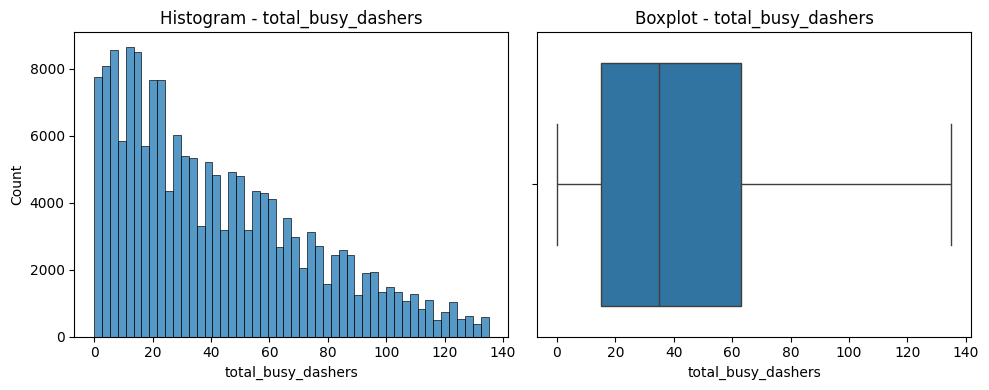

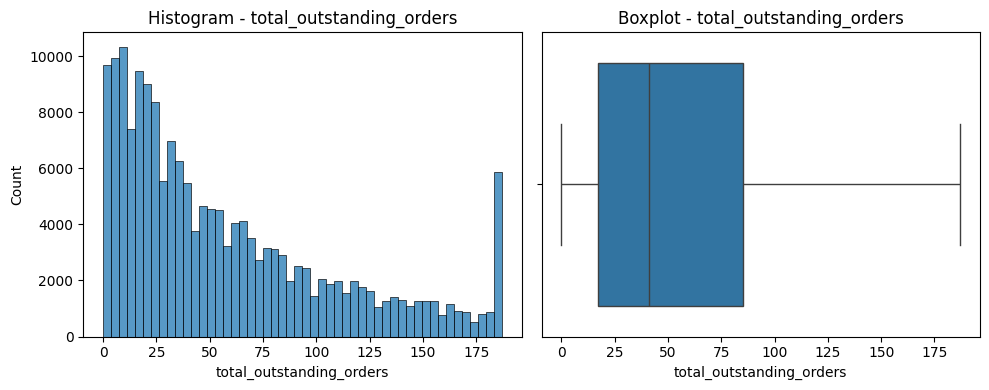

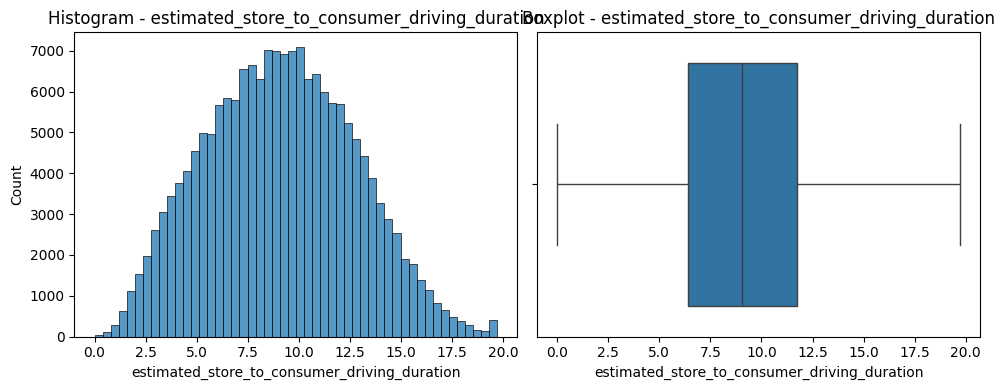

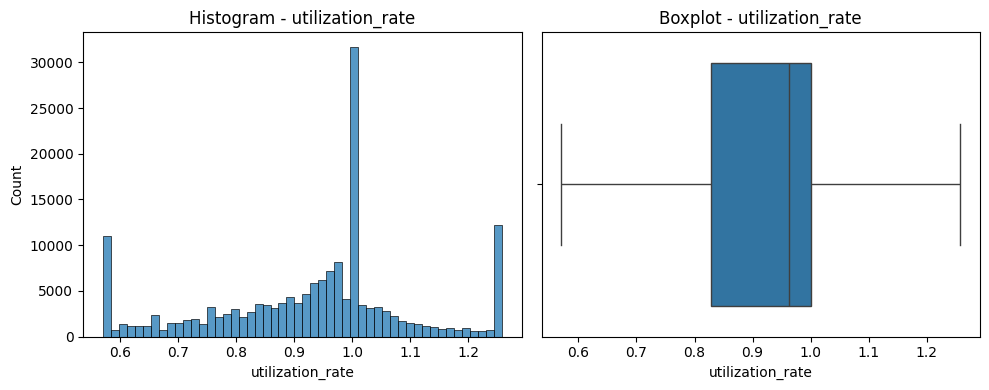

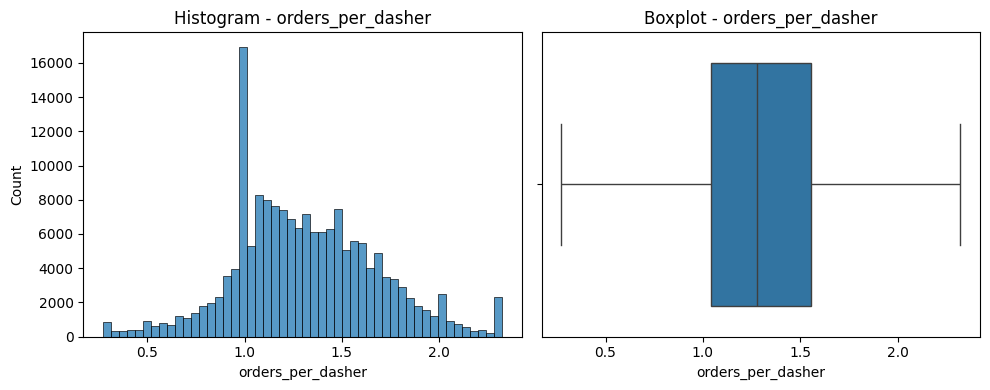

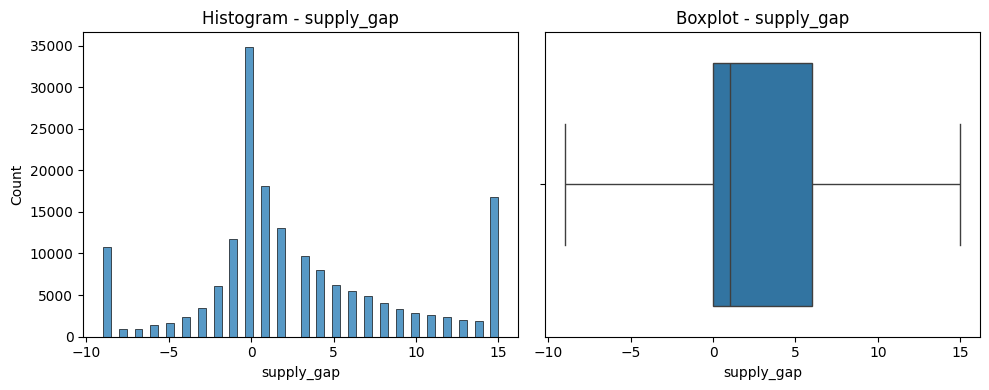

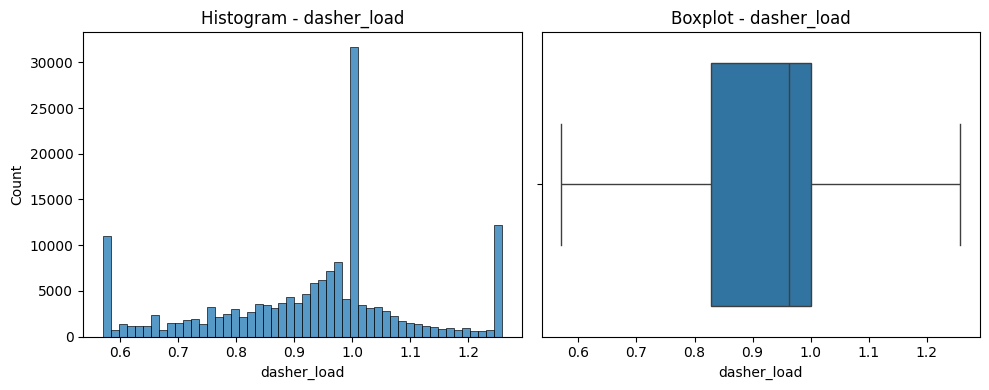

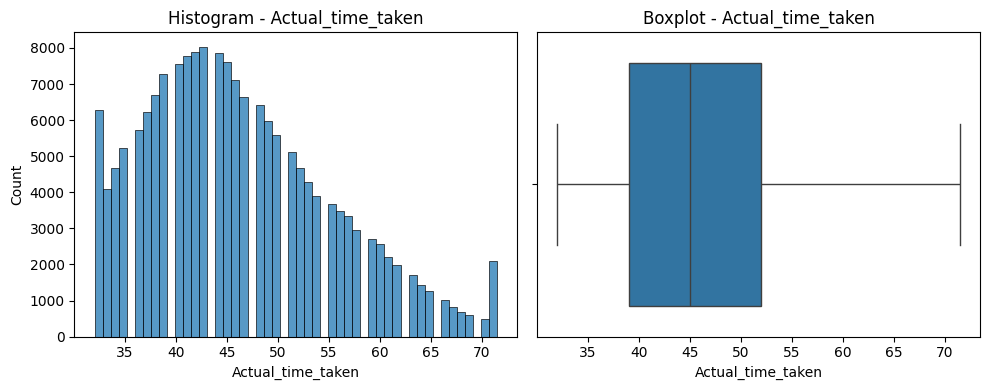

In [17]:
num_uni = ['total_items', 'subtotal', 'min_item_price', 'max_item_price', 'avg_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
           'estimated_store_to_consumer_driving_duration', 'utilization_rate', 'orders_per_dasher', 'supply_gap', 'dasher_load', 'Actual_time_taken' ]
for col in num_uni:

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram (NO KDE, NO tiny binwidth)

    # sns.histplot(np.log1p(df[col]), bins=50, ax = axes[0])
    sns.histplot(df1[col], bins=50, ax=axes[0])
    axes[0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(x=df1[col], ax=axes[1])
    axes[1].set_title(f'Boxplot - {col}')

    plt.tight_layout()
    plt.show()
    #order_per_dasher

- total_onshift_dashers - Most markets have 20–70 dashers available.

- total_busy_dashers - Many dashers are actively engaged with deliveries, High utilization indicates strong demand.

- estimated_driving_duration - Most trips between 6–14 minutes, Delivery delays likely caused by: restaurant prep time, order backlog, driver availability
 &
not distance.

- Utilization Rate - Median appears ≈0.95, means most dashers are busy → system operating near capacity.<br>
However Some values >1, which is theoretically unusual.
  - probabily data lag between busy/on-shift counts
  - aggregation mismatch
  - multiple orders per dasher counted as busy

- Order_per_dasher - around 1.2 – 1.4
    - ~1 order per dasher → healthy system
    - if >1.5 orders per dasher → dashers handling multiple orders → congestion
    - And if < 1 → idle capacity

- Supply_gap : centered around 2-3
    - Positive value → idle dashers available
    - 0 → system fully utilized
    - Negative values → demand exceeds supply

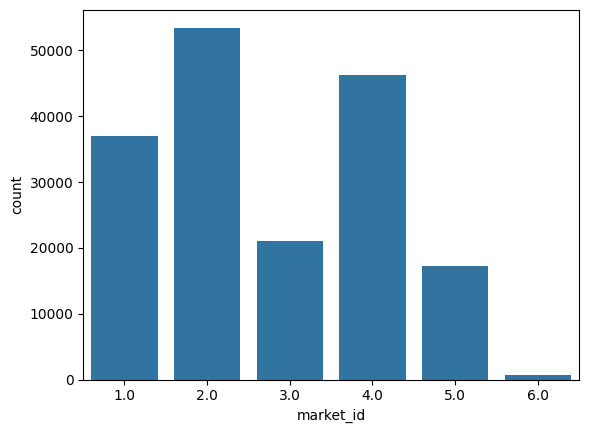

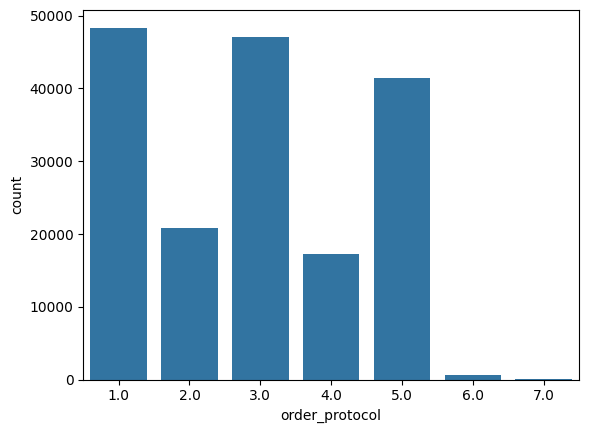

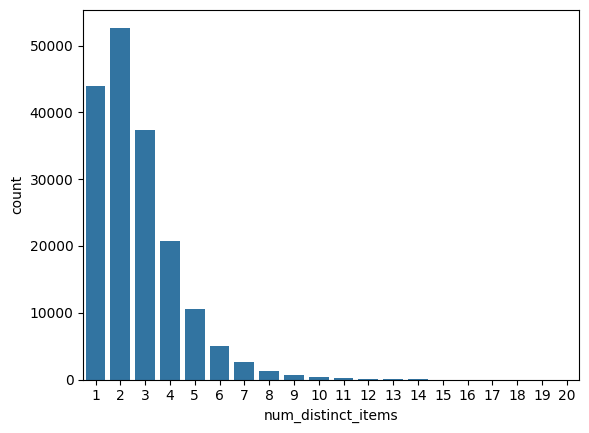

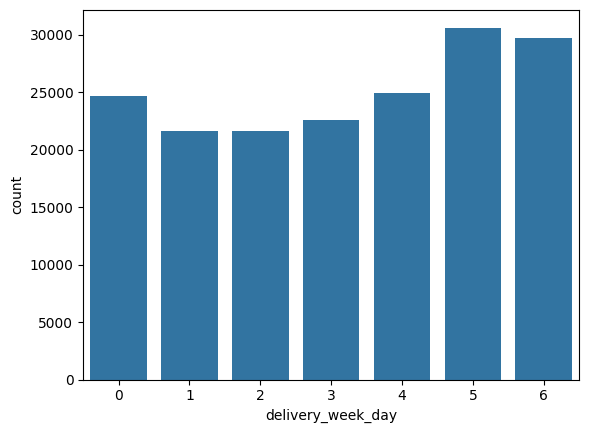

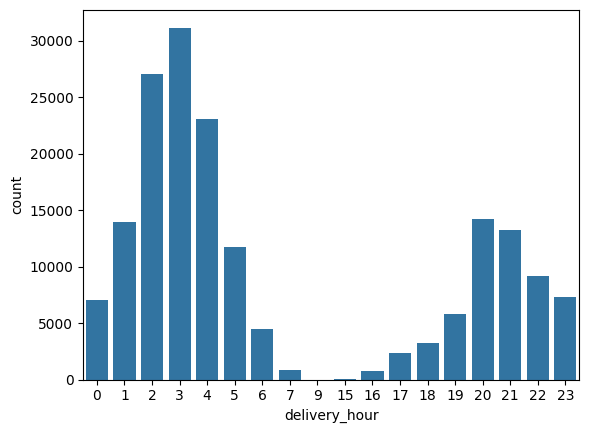

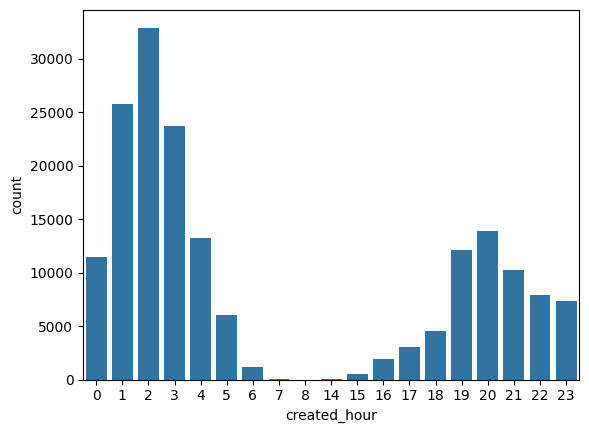

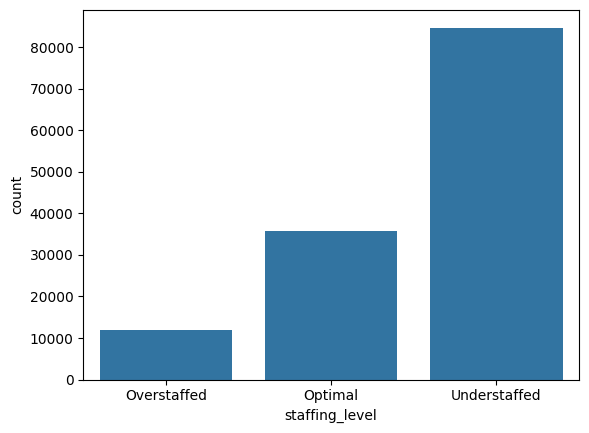

In [18]:
cat_uni = ['market_id', 'order_protocol', 'num_distinct_items', 'delivery_week_day', 'delivery_hour', 'created_hour', 'staffing_level']

for col in  cat_uni:
  sns.countplot(x=df[col].sort_index())
  plt.show()


- Demand : Late night (12–3 AM) → Highest demand
Early morning (3–6 AM) → still high
Daytime (7 AM – 5 PM) → very low demand
Evening (6–10 PM) → moderate demand
Late night again → slight drop

- However in typical demand Lunch peak (12–2 PM)
Dinner peak (6–9 PM).

- But your dataset shows late-night dominance. Possible reasons:
    - Dataset Timezone Shift - The timestamps might be in some other instead of local time.

<Axes: xlabel='store_primary_category', ylabel='count'>

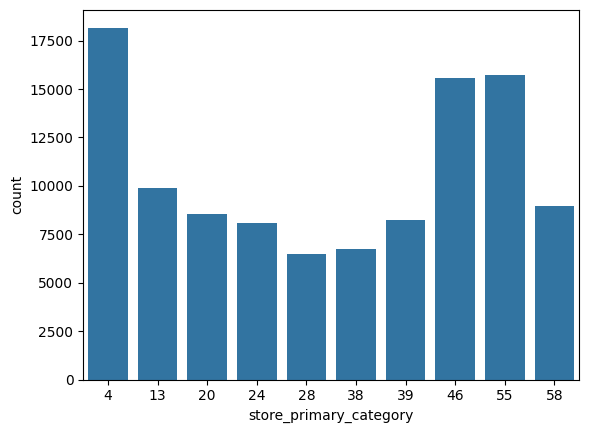

In [19]:
top_10 = df['store_primary_category'].value_counts().nlargest(10).index
store_primary_category_top_10 = df[df['store_primary_category'].isin(top_10)]

sns.countplot(data = store_primary_category_top_10, x = 'store_primary_category')

### Bivarient Analysis

<Axes: xlabel='store_primary_category', ylabel='Approx_Resto_prep_time_min'>

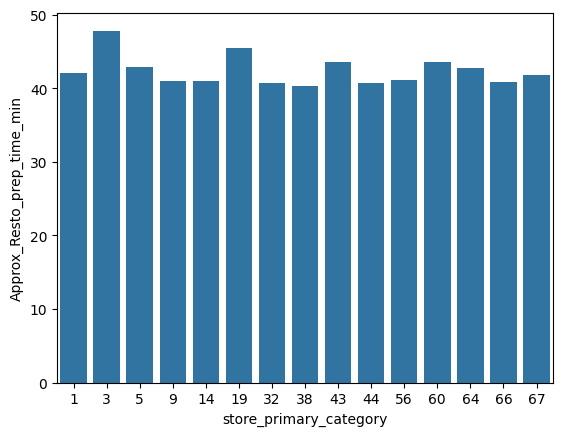

In [26]:
prep_time = (
    df.groupby('store_primary_category')['Approx_Resto_prep_time_min']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

sns.barplot(data=prep_time,
            x='store_primary_category',
            y ='Approx_Resto_prep_time_min')

<Axes: xlabel='market_id', ylabel='Approx_Resto_prep_time_min'>

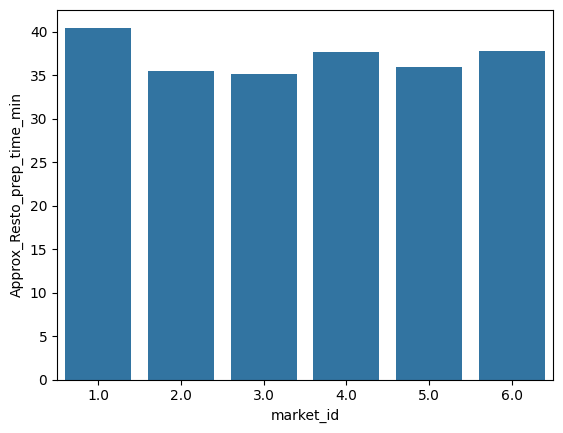

In [27]:
prep_time = (
    df.groupby('market_id')['Approx_Resto_prep_time_min']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

sns.barplot(data=prep_time,
            x='market_id',
            y ='Approx_Resto_prep_time_min')

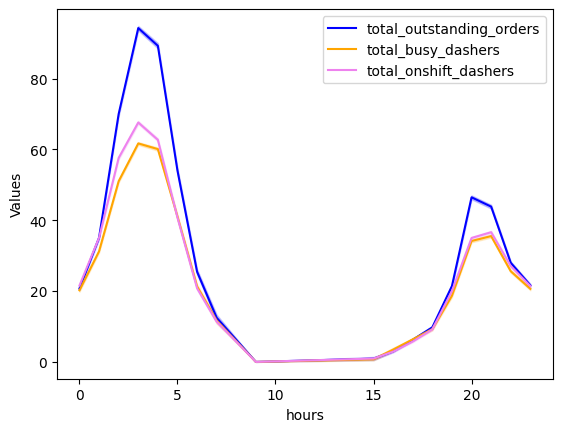

In [29]:
sns.lineplot(data = df, x = 'delivery_hour', y = 'total_outstanding_orders', color = 'blue',label = 'total_outstanding_orders')
sns.lineplot(data = df, x = 'delivery_hour', y = 'total_busy_dashers', color = 'orange', label= 'total_busy_dashers')
sns.lineplot(data = df, x = 'delivery_hour', y = 'total_onshift_dashers', color = 'violet', label= 'total_onshift_dashers')


plt.xlabel('hours')
plt.ylabel('Values')
plt.legend(loc='upper right')
plt.show()

- total_busy_dashers and total_onshift_dashers are almost the same throughout. Which again implies proper utilization happening.
- total_outstanding_orders at peak hours are slightly high, ensuring more dashers during the peak hours. Maybe extra incentive will be better

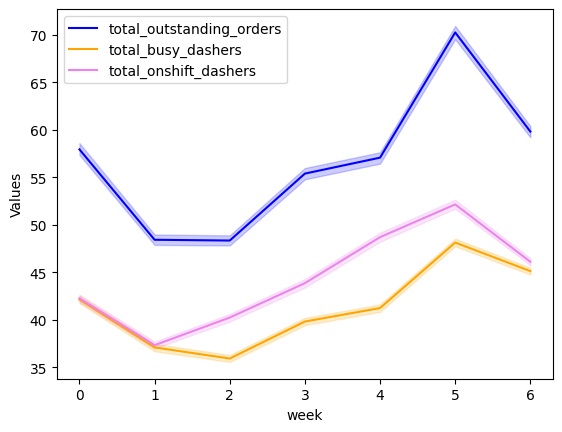

In [21]:
sns.lineplot(data = df, x = 'delivery_week_day', y = 'total_outstanding_orders', color = 'blue',label = 'total_outstanding_orders')
sns.lineplot(data = df, x = 'delivery_week_day', y = 'total_busy_dashers', color = 'orange', label= 'total_busy_dashers')
sns.lineplot(data = df, x = 'delivery_week_day', y = 'total_onshift_dashers', color = 'violet', label= 'total_onshift_dashers')

plt.xlabel('week')
plt.ylabel('Values')
plt.legend(loc='upper left')
plt.show()

- Week day 0, 1 and 6 we see good utilization of busy and onshift dasher. However in Weekday 2, 3, 4, & 5 the total busy dashers are less than onshift dasher, we see some under utilization.
- However we see there are still high outstanding orders, but before increasing the dasher we also need to check why outstanding orders are still high. We saw earlier that the avg time for the dasher to deliver is 10-12 min but the Actual time taken from created to final delivery is around 45-50 min, which suggest the delay may be due to delay
    - at the restaurant
    - assignment of the dashers.

*We might have to check individual markets and other above mentioned reasons before increasing the number of dashers*

In [22]:
df.head(1)

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,...,created_hour,delivery_hour,delivery_week_day,utilization_rate,orders_per_dasher,supply_gap,demand_supply_ratio,staffing_level,dasher_load,avg_item_price
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557.0,1239,...,22,23,4,0.570707,1.5,15.0,0.636364,Overstaffed,0.570707,860.25


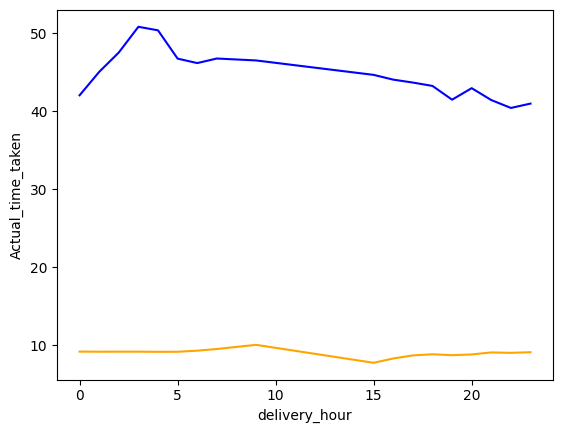

In [23]:
sns.lineplot(data=df.groupby('delivery_hour')['Actual_time_taken'].mean(), color = 'blue')
sns.lineplot(data=df.groupby('delivery_hour')['estimated_store_to_consumer_driving_duration'].mean(), color='orange')

plt.show()

- Estimated_store_to_consumer_driving_duration is around 10 mins
- Actual_time_taken from booking to delivery is approx 40-50 min

<Axes: xlabel='dasher_load', ylabel='Actual_time_taken'>

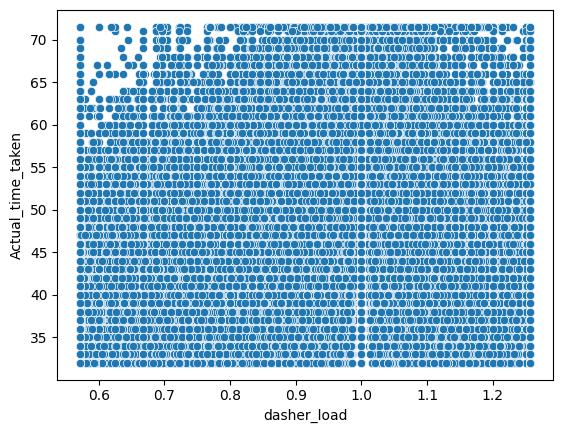

In [24]:
sns.scatterplot(x='dasher_load', y='Actual_time_taken', data=df)

<Axes: xlabel='dasher_load', ylabel='Actual_time_taken'>

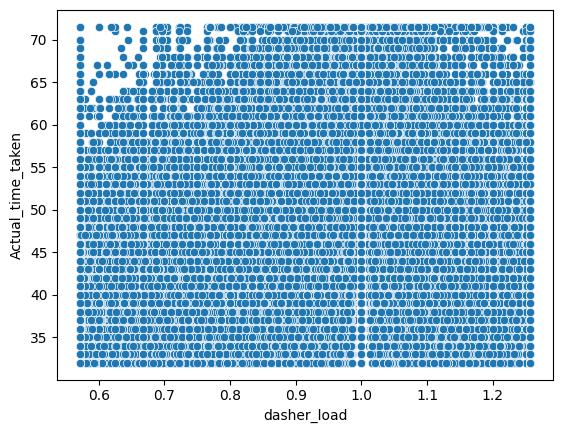

In [25]:
sns.scatterplot(x='dasher_load', y='Actual_time_taken', data=df)

<Axes: xlabel='min_item_price', ylabel='max_item_price'>

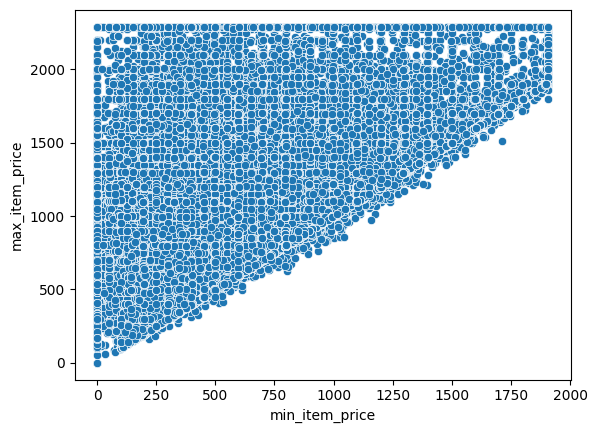

In [26]:
sns.scatterplot(data = df, x = 'min_item_price', y = 'max_item_price')

<Axes: xlabel='total_busy_dashers', ylabel='total_outstanding_orders'>

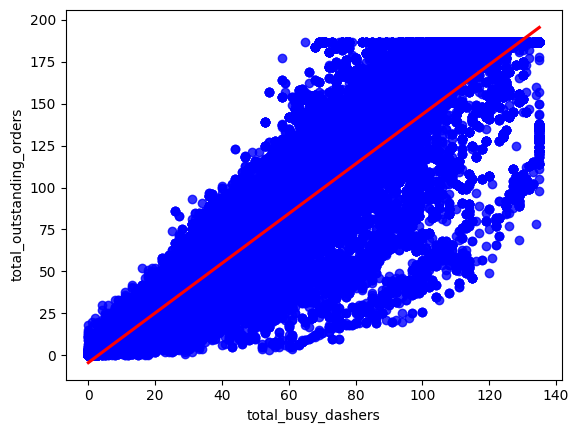

In [27]:
sns.regplot(x='total_busy_dashers', y='total_outstanding_orders', data=df, scatter=True,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'})

### Multivariate Analysis

<Axes: >

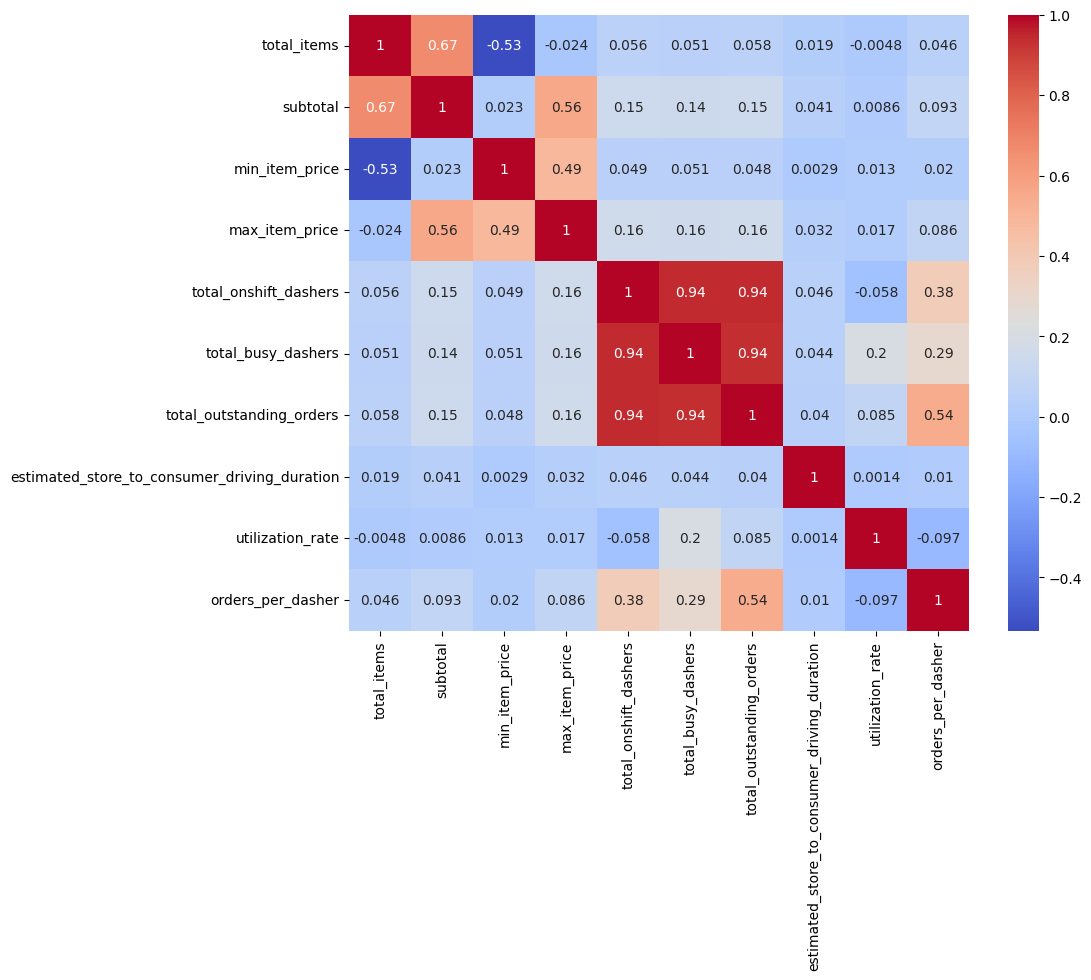

In [28]:
df_copy = df.copy()
df_copy = df_copy[['total_items', 'subtotal', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers',
                   'total_outstanding_orders', 'estimated_store_to_consumer_driving_duration', 'utilization_rate',
    'orders_per_dasher']]
plt.figure(figsize=(10,8))
sns.heatmap(df_copy.corr(), cmap='coolwarm', annot = True)

## AB Testing (Hypotheses Testing)

#### ZTest

In [29]:
top2= df['market_id'].value_counts().nlargest(2).index
top2market_id = df[df['market_id'].isin(top2)]

market2 = df[df['market_id']==2]['Actual_time_taken']
market4 = df[df['market_id']==4]['Actual_time_taken']

<Axes: xlabel='Actual_time_taken', ylabel='Count'>

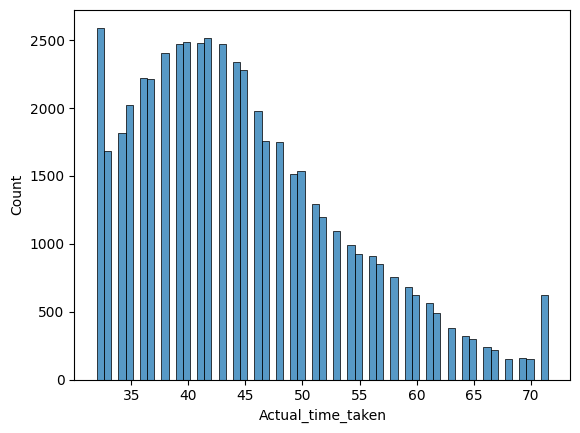

In [30]:
sns.histplot(market2)

In [31]:
# H0: Mean of Actual_time_taken of market2 = market4
# H1: Mean of Actual_time_taken of market2 <> market4
from scipy import stats
from statsmodels.stats.weightstats import ztest

threshold = .05

mean_market2 = market2.mean()
mean_market4 = market4.mean()

# std_market2 = market2.std()
# std_market4 = market4.std()

# n2 = len(market2)
# n4 = len(market4)

# z_stat = (mean_market2 - mean_market4)/np.sqrt((std_market2**2/n2))+(std_market4**2/n4)

# p_val = 2 * (1-stats.norm.cdf(abs(z)))

z_stat, p_val = ztest(market2, market4)

if p_val > threshold:
  print("We fail to reject null hypothesis, therefore Mean of Actual_time_taken of market2 = market4 ")
else:
  print(f"We reject the null hypothesis, p_val {p_val}, therefore Mean of Actual_time_taken of market2 is not equal to  market4")

print(f"Z_Score is {z_stat}")
print(f"mean_market2: {mean_market2}")
print(f"mean_market4: {mean_market4}")

We reject the null hypothesis, p_val 3.5270043603885673e-231, therefore Mean of Actual_time_taken of market2 is not equal to  market4
Z_Score is -32.4632057034818
mean_market2: 44.803243121925675
mean_market4: 46.74741453916054


In [32]:
# t_stat, p_val = stats.ttest_ind(market2, market4, equal_var=False   # Welch’s correction
# )

# print("T-statistic:", t_stat)
# print("P-value:", p_val)

# if p_val > 0.05:
#     print("Fail to reject H0: Means are statistically similar.")
# else:
#     print("Reject H0: Means are statistically different.")

#### ANOVA

In [33]:
protocol1 = df[df['order_protocol']==1]['Actual_time_taken']
protocol2 = df[df['order_protocol']==2]['Actual_time_taken']
protocol3 = df[df['order_protocol']==3]['Actual_time_taken']
protocol4 = df[df['order_protocol']==4]['Actual_time_taken']
protocol5 = df[df['order_protocol']==5]['Actual_time_taken']
protocol6 = df[df['order_protocol']==6]['Actual_time_taken']
protocol7 = df[df['order_protocol']==7]['Actual_time_taken']

Checking for ANOVA assumptions
1. Independence
2. Normality
3. Homogeneity of Variance


In [34]:
# H0: Actual_time_taken for all order_protocol(porter, call to restaurant, prebooked, third part etc) are same
# H1: Actual_time_taken for atleast one order_protocol is not similar

In [35]:
from scipy.stats import shapiro

stat1, pval1 = shapiro(protocol1.sample(500))
stat2, pval2 = shapiro(protocol2.sample(500))
stat3, pval3 =shapiro(protocol3.sample(500))
stat4, pval4 =shapiro(protocol4.sample(500))
stat5, pval5 =shapiro(protocol5.sample(500))
stat6, pval6 =shapiro(protocol6.sample(500))
stat7, pval7 =shapiro(protocol7)

print(pval1,  pval2, pval3, pval4, pval5, pval6, pval7)

1.6539198526657943e-06 5.603315248431201e-10 2.340217734848075e-10 3.3293308650269967e-13 1.5565188942881023e-12 8.42791007834836e-09 0.013256737557530335


In [36]:
from scipy.stats import levene

stat, p = levene(protocol1, protocol2, protocol3, protocol4, protocol5, protocol6, protocol7)

print("Levene p-value:", p)

Levene p-value: 2.7532333715893892e-270


In [37]:
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(protocol1, protocol2, protocol3, protocol4, protocol5, protocol6, protocol7 )

print("F-stat:", f_stat)
print("P-value:", p_val)

if p_val > threshold:
  print("We fail to reject Null Hypothesis, Actual_time_taken for all order_protocol(porter, call to restaurant, prebooked, third part etc) are same")
else:
  print("We reject Null Hypothesis, Actual_time_taken for atleast one order_protocol is not similar")

F-stat: 773.2404206163294
P-value: 0.0
We reject Null Hypothesis, Actual_time_taken for atleast one order_protocol is not similar


In [38]:
# H0: Actual_time_taken for all staffing_level are same
# H1: Actual_time_taken for atleast one staffing_level is not similar

In [39]:
Overstaffed = df[df['staffing_level']=='Overstaffed']['Actual_time_taken']
Optimal = df[df['staffing_level']=='Optimal']['Actual_time_taken']
Understaffed = df[df['staffing_level']=='Understaffed']['Actual_time_taken']


In [40]:
f_stat, p_val = f_oneway(Overstaffed, Optimal, Understaffed )

if p_val > threshold:
  print(f"We fail to reject Null Hypothesis, p_val {p_val}, Actual_time_taken for all staffing_level are same")
else:
  print(f"We reject Null Hypothesis, p_val {p_val}, Actual_time_taken for atleast one staffing_level is not similar")

We reject Null Hypothesis, p_val 0.0, Actual_time_taken for atleast one staffing_level is not similar


#### ChiSquare

In [41]:
# H0: All Variables are independent
# H1: All Variables are not independent

In [42]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['market_id'], df['order_protocol'])

chi2, p, dof, expected = chi2_contingency(contingency)

print(contingency)
print("Chi-square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject H0: Variables are dependent.")
else:
    print("Fail to reject H0: Variables are independent.")

order_protocol    1.0   2.0    3.0   4.0    5.0  6.0  7.0
market_id                                                
1.0             14282  2631   7252  4237   8258  413    0
2.0             10578  7099  16398  3759  15508  124    1
3.0              9196  1865   3694  2971   3259   61    0
4.0              6852  6880  17180  3016  12282   10    0
5.0              7273  2319   2447  3192   1941   65   18
6.0               186    93    140    60    156    3    0
Chi-square: 20959.429814234736
P-value: 0.0
Reject H0: Variables are dependent.


In [43]:
df.head(2)

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,...,created_hour,delivery_hour,delivery_week_day,utilization_rate,orders_per_dasher,supply_gap,demand_supply_ratio,staffing_level,dasher_load,avg_item_price
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557.0,1239,...,22,23,4,0.570707,1.5,15.0,0.636364,Overstaffed,0.570707,860.25
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400.0,1400,...,21,22,1,1.257576,1.0,-1.0,2.000000,NaN,1.257576,1900.00


In [44]:
staff_mapping = {
    'Overstaffed': 0,
    'Optimal': 1,
    'Understaffed': 2
}

df['staffing_level_encoded'] = df['staffing_level'].map(staff_mapping).fillna(1).astype(int)

In [45]:
contingency = pd.crosstab(df['market_id'], df['staffing_level_encoded'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject H0: Variables are dependent.")
else:
    print("Fail to reject H0: Variables are independent.")

Chi-square: 5954.431509897398
P-value: 0.0
Reject H0: Variables are dependent.


In [46]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration', 'Actual_time_taken',
       'created_hour', 'delivery_hour', 'delivery_week_day',
       'utilization_rate', 'orders_per_dasher', 'supply_gap',
       'demand_supply_ratio', 'staffing_level', 'dasher_load',
       'avg_item_price', 'staffing_level_encoded'],
      dtype='object')

## Training ML models

In [47]:
df['utilization_rate'] = np.where(df['total_onshift_dashers']==0,
                                  0,
                                  df['total_busy_dashers']/df['total_onshift_dashers'])

In [48]:
features = ['market_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers',
            'total_outstanding_orders', 'estimated_store_to_consumer_driving_duration', 'created_hour', 'delivery_week_day', 'utilization_rate', 'orders_per_dasher', 'supply_gap',
            'dasher_load', 'avg_item_price', 'staffing_level_encoded']

X = df[features]
y = df['Actual_time_taken']


In [49]:
# Since few of the featured engineered columns were having some infinite values, we first replaces those infinite values to nan and then filled the nan with its median.
X = df[features]

# Replace inf everywhere
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing
X = X.fillna(X.median())

#### Linear Regression

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(f"LR MAE : , {mean_absolute_error(y_test, y_pred_lr)}, it mean the predictions are off by {mean_absolute_error(y_test, y_pred_lr)} minutes")
print("LR MSE : ", mean_squared_error(y_test, y_pred_lr))
print("LR RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

LR MAE : , 2.4190846023245105, it mean the predictions are off by 2.4190846023245105 minutes
LR MSE :  10.4889282972247
LR RMSE : 3.2386614977834127


#### Random Forest Regressor

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

RF MAE: 1.1925056203756406
RF RMSE: 1.6365578509465768


#### XG Boost Regressor

In [52]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGB MAE: 0.8460118187919013
XGB RMSE: 1.1510714070773949


In [53]:
results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
}

import pandas as pd
pd.DataFrame(results)

,Model,MAE,RMSE
0,Linear Regression,2.419085,3.238661
1,Random Forest,1.192506,1.636558
2,XGBoost,0.846012,1.151071


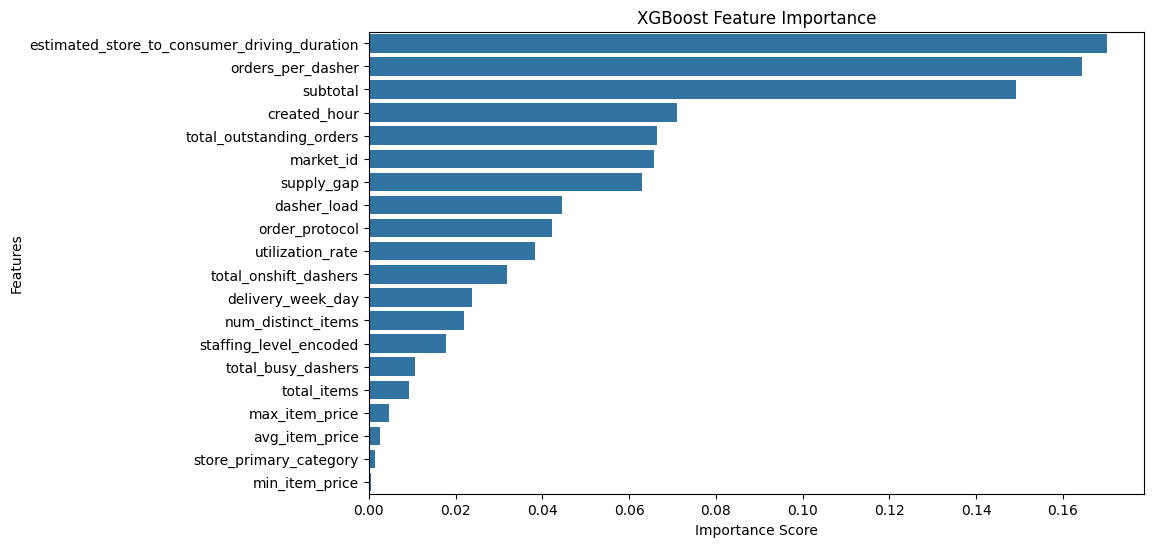

In [54]:
importance = xgb.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

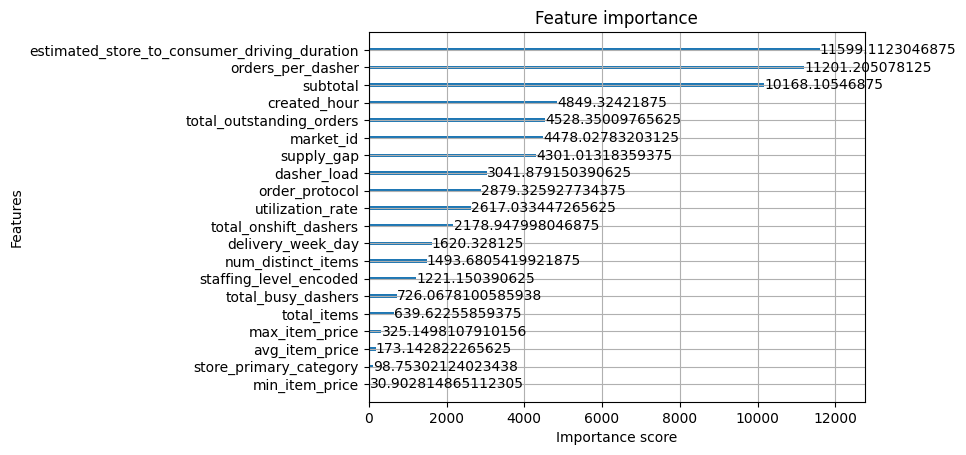

In [55]:
from xgboost import plot_importance

plot_importance(xgb, importance_type='gain')
plt.show()

- XGBoost achieved the lowest MAE (0.846) and RMSE (1.151) among all models. This means its prediction error is the smallest, making it the most accurate model.
- Random Forest significantly improved over Linear Regression
- The model can help:
    - Predict delivery delays
    - Optimize dasher allocation
    - Improve delivery time estimates shown to customers

## Neural Network

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
            Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
            Dropout(0.2),
            Dense(64, activation='relu'),
            Dense(1)
                  ])

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae']
             )

model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=256)

nn_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 770.7872 - mae: 21.0540 - val_loss: 22.0647 - val_mae: 3.6036
Epoch 2/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.6314 - mae: 4.1995 - val_loss: 11.7388 - val_mae: 2.6633
Epoch 3/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 19.5810 - mae: 3.4911 - val_loss: 7.7967 - val_mae: 2.1693
Epoch 4/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 15.5893 - mae: 3.1030 - val_loss: 5.6332 - val_mae: 1.8191
Epoch 5/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13.0677 - mae: 2.8311 - val_loss: 4.4853 - val_mae: 1.5743
Epoch 6/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11.0946 - mae: 2.6016 - val_loss: 3.9427 - val_mae: 1.4577
Epoch 7/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.3908 - mae: 2.4967 - val_loss: 3.5459 - val_mae: 1.3662
Epoch 8/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.6279 - mae: 2.3893 - val_loss: 3.2585 - val_mae: 1.2874
Epoch 9/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

- Neural Network Achieved Low Prediction Error. The validation MAE is 0.6116, meaning the model's predictions are on average 0.61 units away from the actual delivery time. Training MAE = 0.638 which suggest its not overfitting.

## NN with Regression and Classification:


 - Delivery Time Predictio
 - Staffing Level Prediction (overstaffed, optimally staffed, understaffed)

Multi-Task Learning Works Here as both predictions depend on similar operational factors:
  - total busy dashers
  - outstanding orders
  - order volume
  - travel time

Instead of building separate models for delivery time and staffing classification, I implemented a multi-task neural network with shared feature layers. This allows the model to learn operational relationships between demand, supply, and delivery performance, improving predictive capability for both tasks.

In [57]:
y_reg = df['Actual_time_taken']
y_class = df['staffing_level_encoded']

In [58]:
X_train, X_test, y_reg_train, y_reg_test, y_class_train, y_class_test = train_test_split(X, y_reg, y_class, test_size=0.2, random_state=42)

In [59]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_layer = Input(shape=(X_train_scaled.shape[1],))

shared = Dense(128, activation='relu')(input_layer)
shared = Dense(64, activation='relu')(shared)

# Regression output
reg_output = Dense(1, name='time_output')(shared)

# Classification output
class_output = Dense(3, activation='softmax', name='staff_output')(shared)

model = Model(inputs=input_layer, outputs=[reg_output, class_output])

model.compile(
    optimizer='adam',
    loss={
        'time_output': 'mse',
        'staff_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'time_output': 'mae',
        'staff_output': 'accuracy'
    }
)

model.fit(
    X_train_scaled,
    {
        'time_output': y_reg_train,
        'staff_output': y_class_train
    },
    epochs=50,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 703.2746 - staff_output_accuracy: 0.6028 - staff_output_loss: 0.8507 - time_output_loss: 702.4222 - time_output_mae: 19.7480 - val_loss: 21.3779 - val_staff_output_accuracy: 0.9262 - val_staff_output_loss: 0.3346 - val_time_output_loss: 21.0356 - val_time_output_mae: 3.5630
Epoch 2/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17.8065 - staff_output_accuracy: 0.9396 - staff_output_loss: 0.2283 - time_output_loss: 17.5782 - time_output_mae: 3.2481 - val_loss: 11.0699 - val_staff_output_accuracy: 0.9973 - val_staff_output_loss: 0.0456 - val_time_output_loss: 11.0198 - val_time_output_mae: 2.5949
Epoch 3/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.8966 - staff_output_accuracy: 0.9982 - staff_output_loss: 0.0289 - time_output_loss: 9.8676 - time_output_mae: 2.4560 - val_loss: 6.9394 - val_staff_output_accuracy: 0.9994 - val_staff_output_loss: 0.0086 - val_time_output_loss: 6.9281 - val_time_output_mae: 2.0539
Epoch

**Delivery Time (Regression)**
- Validation MAE ≈ 0.463
- Validation MSE ≈ 0.4635

The neural network achieved a very low prediction error, without overfitting

Interpretation

This indicates the model has learned the relationship between:

driver availability

order demand

travel distance

order size

**Staffing Level (Classification)**
Validation Accuracy ≈ 100%


The model perfectly classifies whether a market is:

- Overstaffed
- Optimal
- Understaffed

The model perfectly classifies whether a market is Overstaffed, Optimal, Understaffed
Interpretation

This indicates the model has learned the relationship between:

driver availability

order demand

travel distance

order size

##💡 Business Recommendations
1 **Monitor Driver Utilization**

Platforms should continuously track the ratio of busy dashers to on-shift dashers to identify periods of high driver workload and potential delivery delays.

2 **Manage Order Demand During Peak Periods**

When outstanding orders increase significantly, operational systems should trigger mechanisms such as temporary driver incentives or load balancing across nearby markets.

3 **Improve Staffing Forecasting**

Historical patterns in outstanding orders and driver availability can be used to forecast staffing needs and ensure sufficient drivers are available during high-demand periods.

4 **Optimize Order Assignment**

Orders should be distributed efficiently among available dashers to prevent certain drivers from becoming overloaded while others remain idle.

5 **Use Predictive ETA Models**

Machine learning models predicting delivery time can be integrated into the platform to provide customers with more reliable delivery estimates.

6 **Monitor Order Complexity**

Orders with larger numbers of items or higher subtotals may require additional preparation time, which should be considered when estimating delivery times.

7 **Integrate Data-Driven Decision Making**

Operational dashboards that incorporate predictive insights can help managers quickly detect staffing imbalances and respond proactively.

##📌 Project Conclusion

This project analyzed delivery marketplace operations to understand the factors influencing order fulfillment time and staffing conditions. Using exploratory data analysis, feature engineering, hypothesis testing, and predictive modeling, key operational drivers such as the number of busy dashers, on-shift dashers, outstanding orders, and order size were identified. Machine learning models, including ensemble methods and neural networks, were developed to predict delivery time and classify staffing levels based on these operational variables.

The results demonstrate that marketplace balance between order demand and driver availability plays a critical role in delivery efficiency. Predictive models built in this study provide a data-driven framework for estimating delivery time and identifying potential staffing imbalances. These insights can support operational decision-making and help delivery platforms improve efficiency and service reliability.

## Leading Questions:

1. Defining the Problem Statement and Its Applications

The goal of this project is to analyze operational delivery data to predict actual delivery time and staffing conditions using machine learning and neural networks.
This type of analysis can be applied in food delivery platforms, ride-sharing services, logistics companies, and warehouse operations to optimize resource allocation and improve service efficiency.

2. Three pandas Datetime Functions

    1. pd.to_datetime() - Converts strings or other formats into pandas datetime objects for easier time-based analysis.

   2. .dt.hour - Extracts the hour component from a datetime column to analyze time-of-day patterns.

   3. .dt.dayofweek - Returns the day of the week (0–6), useful for identifying weekday vs weekend trends.

3. Short Note on Datetime, Timedelta, and Time Span (Period)

    Datetime - Represents a specific date and time, allowing precise timestamp-based analysis in datasets.
    Timedelta - Represents the difference between two datetime values and is commonly used to calculate durations.
    Time Span (Period) - Represents a defined interval of time such as a day, week, or month, useful for grouping time-based data.

4. Why Do We Need to Check for Outliers?

Outliers can distort statistical analysis and negatively impact machine learning models by introducing extreme values that do not represent normal data patterns.

5. Three Outlier Removal Methods

    - Z-Score Method – Identifies values that are several standard deviations away from the mean.

    - IQR (Interquartile Range) Method – Detects outliers using the range between the first and third quartiles.

    - Isolation Forest – A machine learning method that detects anomalies by isolating unusual observations.

6. Classical Machine Learning Methods for This Problem

    - Linear Regression – For predicting continuous delivery time values.

    - Random Forest Regressor – For capturing nonlinear relationships between operational variables.

    - XGBoost – A gradient boosting algorithm that provides strong predictive performance for structured data.

7. Why is Scaling Required for Neural Networks?

Scaling ensures that all input features have a similar range, which helps neural networks converge faster and prevents certain features from dominating the learning process.

8. Choice of Optimizer

The Adam optimizer was used because it combines the advantages of momentum and adaptive learning rates, allowing faster and more stable convergence during training.

9. Activation Function Used and Why

The ReLU (Rectified Linear Unit) activation function was used in hidden layers because it improves training efficiency and helps mitigate the vanishing gradient problem.

10. Why Neural Networks Perform Well on Large Datasets

Neural networks perform well on large datasets because they can learn complex nonlinear relationships and hierarchical feature representations when sufficient data is available.